### 1-1-1. 파생변수란

<aside>
💡

파생변수는 기존의 변수들을 조합하거나 연산하여 새롭게 만들어진 변수를 말한다. 이는 분석 목적에 맞게 데이터를 재구성하여 모델의 성능을 향상시키는 데 도움이 된다.

</aside>

In [4]:
import pandas as pd

# 예시 데이터프레임 생성
data = {'customer_id': [1, 2, 3],
        'purchase1': [100, 200, 150],
        'purchase2': [80, 120, 130]}
df = pd.DataFrame(data)
df

,customer_id,purchase1,purchase2
0,1,100,80
1,2,200,120
2,3,150,130


In [5]:
df["total_purchase"] = df['purchase1'] + df['purchase2']
df

,customer_id,purchase1,purchase2,total_purchase
0,1,100,80,180
1,2,200,120,320
2,3,150,130,280


### 1-2-1. 요약변수란

<aside>
💡

요약변수는 데이터를 그룹화하여 특정 집단의 통계량(평균, 합계 등)을 나타내는 변수이다. 이는 데이터의 전반적인 경향을 파악하거나 비교 분석할 때 유용하다.

</aside>

In [6]:
data = {'region': ['A', 'A', 'B', 'B', 'C'],
        'income': [5000, 6000, 5500, 6200, 5800]}
df = pd.DataFrame(data)
df

,region,income
0,A,5000
1,A,6000
2,B,5500
3,B,6200
4,C,5800


In [9]:
region_avg_income = df.groupby('region')['income'].mean().reset_index()
region_avg_income.rename(columns={'income': 'avg_income'}, inplace=True)
print(region_avg_income)

  region  avg_income
0      A      5500.0
1      B      5850.0
2      C      5800.0


In [8]:
# transform() : 매개변수의 기준에 따라 계산하고 원래 행의 개수만큼 반환
avg_income = df.groupby('region')['income'].transform('mean')
avg_income

0    5500.0
1    5500.0
2    5850.0
3    5850.0
4    5800.0
Name: income, dtype: float64

## 1-3. 기준점 정의

### 1-3-1. 기준점이란

<aside>
💡

데이터 분석에서 기준점은 비교나 평가의 기준이 되는 값을 의미한다. 이는 데이터의 상대적 위치나 변화를 파악하는 데 활용된다.

</aside>

In [11]:
data = {'person': ['X', 'Y', 'Z'],
        'income': [4000, 5000, 6000]}
df = pd.DataFrame(data)
df

,person,income
0,X,4000
1,Y,5000
2,Z,6000


In [13]:
# 전체 평균 소득
mean_income = df["income"].mean()
mean_income
# 전체평균과 값의 차이
df['income_diff'] = df['income'] - mean_income
df

np.float64(5000.0)

In [19]:
data = {'region': ['A', 'B', 'C', 'D'],
        'avg_income': [5500, 5000, 6000, 4500]}
df = pd.DataFrame(data)


mean_income = df["avg_income"].mean()

def categorize_income(x):
    if x > mean_income:
        return '높음'
    elif x == mean_income:
        return '보통'
    else:
        return '낮음'

# df['income_level'] = df['avg_income'].

df['income_level'] = df['avg_income'].apply(categorize_income)
df

,region,avg_income,income_level
0,A,5500,높음
1,B,5000,낮음
2,C,6000,높음
3,D,4500,낮음


# 2. 결측값 처리

<aside>
💡

결측값은 데이터 수집 과정에서 누락된 값을 의미하며, 분석 결과에 영향을 미칠 수 있으므로 적절한 처리가 필요하다.

</aside>

## 2-1. 결측값 처리 방법

<aside>
💡

결측값 처리는 크게 삭제와 대치 방법으로 나뉜다.

- **삭제 방법**: 결측값이 있는 관측치를 제거한다.
- **대치 방법**: 결측값을 다른 값으로 대체한다.
</aside>

### 2-1-1. 평균대치법

- 결측값을 해당 변수의 평균값으로 대체하는 방법이다.
- **예시**: 나이 변수의 결측값을 평균 나이로 대체한다.

In [43]:
import pandas as pd
import numpy as np

# 예시 데이터프레임 생성
data = {'name': ['Alice', 'Bob', 'Charlie', 'David'],
        'age': [25, np.nan, 30, np.nan]}
df = pd.DataFrame(data)
df.info()
df.isna()
df.isnull()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    4 non-null      str    
 1   age     2 non-null      float64
dtypes: float64(1), str(1)
memory usage: 196.0 bytes


,name,age
0,False,False
1,False,True
2,False,False
3,False,True


In [44]:
df.isna().sum()

name    0
age     2
dtype: int64

In [45]:
df['age'] = df['age'].fillna(df['age'].mean())
df

,name,age
0,Alice,25.0
1,Bob,27.5
2,Charlie,30.0
3,David,27.5


### 2-1-2. 단순확률대치법

- 결측값을 변수의 분포에 따라 무작위로 대체하는 방법이다.
- **예시:** 시험 점수의 결측값을 기존 점수 분포에 따라 무작위로 대체한다.

In [75]:
# 예시 데이터프레임 생성
data = {'student': ['A', 'B', 'C', 'D', 'E'],
        'score': [80, np.nan, 90, np.nan, 85]}
df = pd.DataFrame(data)



In [76]:
# 결측치 위치 확인
nan_indices = df[df["score"].isnull()].index
nan_indices

RangeIndex(start=1, stop=5, step=2)

In [89]:
df.loc[nan_indices, 'score'] = np.random.choice(
    df['score'].dropna(), size=len(nan_indices))

df

,student,score
0,A,80.0
1,B,85.0
2,C,90.0
3,D,80.0
4,E,85.0


### 2-1-3. 다중대치법

- 결측값을 여러 번 대체하여 그 불확실성을 반영하는 방법이다.
- **예시:** 다중대치법을 사용하여 데이터프레임의 결측값을 대체한다.

In [90]:
%pip install scikit-learn


   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -------------------- ------------------- 4.2/8.2 MB 21.4 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 26.6 MB/s  0:00:00

   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------- ----------------------------- 1/4 [narwhals]
   ---------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [92]:
import pandas as pd
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 예시 데이터프레임 생성
data = {'feature1': [1.0, 2.1, np.nan, 4.3, 5.2],
        'feature2': [3.2, np.nan, 1.8, 2.5, 4.0]}
df = pd.DataFrame(data)
df

,feature1,feature2
0,1.0,3.2
1,2.1,NaN
2,NaN,1.8
3,4.3,2.5
4,5.2,4.0


In [93]:
df.columns

Index(['feature1', 'feature2'], dtype='str')

In [ ]:
# 다중대치법
# 반복값 결측갑 대체 모델
# IterativeImputer : 반복값 결측값 대체 모델(10번 반복, 시드 고정)

imputer = IterativeImputer(max_iter=10, random_state=0)
df_inputed = pd.DataFrame(imputer.fit_transform(df), columns= df.columns)
df_inputed


,feature1,feature2
0,1.000000,3.200000
1,2.100000,2.874009
2,3.148439,1.800000
3,4.300000,2.500000
4,5.200000,4.000000


# 3. 이상값 처리

<aside>
💡

이상값은 데이터 분포에서 멀리 떨어진 값으로, 분석 결과에 큰 영향을 미칠 수 있으므로 적절한 식별과 처리가 필요하다.

</aside>

## 3-1. 이상값 인식 방법

<aside>
💡

- **표준편차 활용**: 평균에서 ±3표준편차를 벗어나는 값을 이상값으로 간주한다.
- **사분위 범위(IQR) 활용**: 1사분위수와 3사분위수를 이용하여 이상값을 식별한다.
</aside>

### 3-1-1. ESD/사분위 범위 활용

- **사분위 범위(IQR)를 이용한 이상값 식별 방법**
    - **IQR 계산**: IQR = Q3 - Q1
    - **이상값 기준**:
        - 하한선 = Q1 - 1.5 * IQR
        - 상한선 = Q3 + 1.5 * IQR

In [97]:

# 예시 데이터프레임 생성
data = {'value': [10, 12, 14, 16, 18, 100]}
df = pd.DataFrame(data)

In [98]:
# 사분위수 계산
Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)
IQR = Q3 - Q1
print(Q1, Q3, IQR)

12.5 17.5 5.0


In [100]:
# 이상값 기준 계산
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

5.0 25.0


In [ ]:
# 이상값 식별
outliers = df[(df['value'] < lower_bound) | (df["value"] > upper_bound)]
outliers

,value
5,100


### 3-1-2. 산점도 그래프 활용

- 산점도를 통해 이상값을 시각적으로 확인할 수 있다.

In [108]:
import pandas as pd
import matplotlib.pyplot as plt

# 예시 데이터프레임 생성
data = {'value': [10, 12, 14, 16, 18, 100]}
df = pd.DataFrame(data)
df

,value
0,10
1,12
2,14
3,16
4,18
5,100


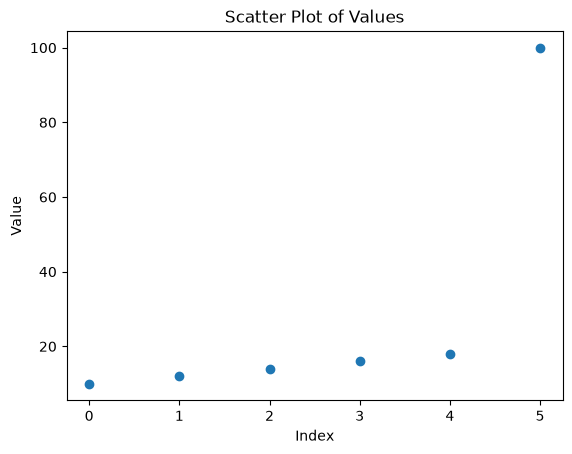

In [109]:
# 산점도 그리기
plt.scatter(df.index, df['value'])
plt.title('Scatter Plot of Values')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

# 4. 데이터 정규화

<aside>
💡

데이터 정규화는 변수 간 단위 차이를 제거하여 분석의 효율성을 높이는 과정이다.

</aside>

## 4-1. 표준정규분포 Z-변환

### 4-1-1. 표준정규분포란

<aside>
💡

표준정규분포는 평균이 0이고 분산(또는 표준편차 제곱)이 1인 정규분포를 말한다. 이는 확률 이론과 통계학에서 매우 중요한 역할을 하며, 다양한 통계 분석과 가설 검정에서 기본이 되는 분포이다.

- **평균(기댓값, μ)**: 0
- **표준편차(σ)**: 1
</aside>

- 정규분포는 연속 확률 분포 중 하나로, 종 모양의 대칭적인 곡선을 그린다. 정규분포는 평균과 표준편차에 따라 그 형태가 결정되며, 표준정규분포는 평균을 0으로, 표준편차를 1로 표준화한 특별한 경우이다.

### 4-1-2. Z-변환


<aside>
💡

Z-변환은 데이터를 평균이 0이고 표준편차가 1인 정규분포로 변환하는 방법이다.

</aside>

$$
z=\frac{X - \mu}{\sigma}
$$

- x:  원본 데이터 값
- μ: 평균
- σ: 표준편차
- z: 변환된 표준화 값

In [110]:
import pandas as pd

# 예시 데이터프레임 생성
data = {'score': [70, 80, 90, 100, 110]}
df = pd.DataFrame(data)

# 평균과 표준편차 계산
mean = df['score'].mean()
std = df['score'].std()

# Z-변환 적용
df['z_score'] = (df['score'] - mean) / std
print(df)

   score   z_score
0     70 -1.264911
1     80 -0.632456
2     90  0.000000
3    100  0.632456
4    110  1.264911


### StandardScaler 사용

In [111]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
# 예시 데이터프레임 생성

data = {'score': [70, 80, 90, 100, 110]}
df = pd.DataFrame(data)
df

,score
0,70
1,80
2,90
3,100
4,110


In [113]:
df[['score']]

,score
0,70
1,80
2,90
3,100
4,110


In [ ]:
# StandardScaler() 를 사용하여 z 변환 간편화
scaler = StandardScaler()

df['z_score'] = scaler.fit_transform(df[['score']]) # 대괄호 두개를 줘서 데이터프레임 양식 그대로 사용
df

StandardScaler()


## 4-2. [0-1] 변환

### 4-2-1. [0-1] 변환이란

<aside>
💡

데이터를 0과 1 사이의 값으로 스케일링하는 방법이다.

</aside>

### 4-2-2. [0-1] 변환 공식

$$
⁡X_{\text{normalized}} = \frac{X - X_{\min}}{X_{\max} - X_{\min}}
$$

- X: 원본 데이터 값
- Xmin: 데이터의 최소값
- Xmax: 데이터의 최대값

In [117]:
# 예시 데이터프레임 생성
data = {'score': [70, 80, 90, 100, 110]}
df = pd.DataFrame(data)

df

,score
0,70
1,80
2,90
3,100
4,110


In [118]:
# 최소값과 최대값 계산
min_val = df['score'].min()
max_val = df['score'].max()

print(min_val)
print(max_val)

70
110


In [119]:
# [0-1] 변환 적용
df['normalized_score'] = (df['score'] - min_val) / (max_val - min_val)
print(df)

   score  normalized_score
0     70              0.00
1     80              0.25
2     90              0.50
3    100              0.75
4    110              1.00


### MinMaxScaler 사용

In [120]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

data = {'score': [70, 80, 90, 100, 110]}
df = pd.DataFrame(data)
df

,score
0,70
1,80
2,90
3,100
4,110


In [121]:
scaler = MinMaxScaler()

df["normalized_score"] = scaler.fit_transform(df[["score"]])
df

,score,normalized_score
0,70,0.00
1,80,0.25
2,90,0.50
3,100,0.75
4,110,1.00


### 4-3-1. 중심극한정리란

<aside>
💡

중심극한정리는 표본의 크기가 충분히 크다면, 모수에 관계없이 표본평균의 분포가 정규분포에 가까워진다는 이론이다.

</aside>

### 4-3-2. 중심극한정리 수식

- **표본평균의 기대값**
    
    $$
    E(\bar{X}) = \mu
    $$
    
- **표본평균의 분산**
    
    $$
    Var(\bar{X}) = \frac{\sigma^2}{n}
    $$
    
    - μ: 모평균
    - σ2: 모분산
    - n: 표본 크기

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 표본 크기와 시도 횟수 설정
n = 30  # 표본 크기
trials = 10000  # 시도 횟수

# 표본 평균 저장 리스트
sample_means = []

for _ in range(trials):
    # 1부터 6까지의 숫자를 랜덤으로 n(30)개 뽑음(결과 : 리스트)
    samples= np.random.randint(1, 7, n) 
    sample_means.append(np.mean(samples)) # 결과를 평균내서 평균저장리스트에 추가

print(samples)

[5 5 4 6 5 3 6 1 5 1 1 1 4 1 4 4 4 5 3 6 6 2 3 5 3 1 1 2 2 4]


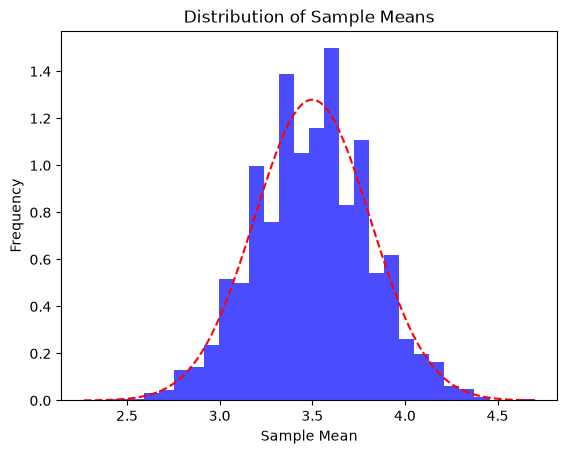

In [ ]:
# 히스토그램 그리기
plt.hist(sample_means, bins=30, density=True, alpha= 0.7, color="blue")



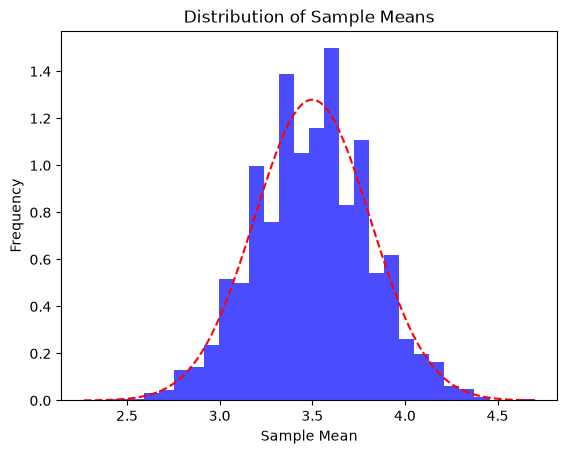

In [ ]:
plt.hist(sample_means, bins=30, density=True, alpha= 0.7, color="blue")

# 정규분포 곡선 그리기
from scipy.stats import norm
mu = 3.5 # 주사위 눈 평균
dice = [1,2,3,4,5,6]
sigma = np.sqrt(35/12) / np.sqrt(n) # 주사위 눈의 분산과 표본크기를 이용한 표준편차

# np.mean(dice)
# np.std(dice)


x = np.linspace(min(sample_means), max(sample_means), 100)
plt.plot(x, norm.pdf(x, mu, sigma), 'r--')

plt.title('Distribution of Sample Means')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')
plt.show()

